# Objectives

- Create informative and visually appealing plots with Matplotlib and Seaborn.
- Apply visualization to communicate insights from the data.
- Analyze data through using visualizations.
- Customize visualizations

### Installing Required Libraries

In [1]:
%pip install pandas
%pip install numpy
%pip install seaborn
%pip install folium

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


### Importing Required Libraries

In [5]:
import numpy as np
import pandas as pd
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import folium

# Importing Data

In [2]:
import requests
import io
import pandas as pd

# URL of the CSV file
URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/d51iMGfp_t0QpO30Lym-dw/automobile-sales.csv"

# Fetch the data from the URL
response = requests.get(URL)

# Raise an error if the request failed
response.raise_for_status()

# Convert the response content into a readable format for pandas
csv_content = io.StringIO(response.text)

# Read the CSV data into a pandas dataframe
df = pd.read_csv(csv_content)

# Print confirmation
print('Data downloaded and read into a dataframe!')

# Optional: Show the first few rows of the dataframe
print(df.head())

Data downloaded and read into a dataframe!
         Date  Year Month  Recession  Consumer_Confidence  Seasonality_Weight  \
0  1980-01-31  1980   Jan          1               108.24                0.45   
1  1980-01-31  1980   Jan          1               108.24                0.45   
2  1980-01-31  1980   Jan          1               108.24                0.36   
3  1980-01-31  1980   Jan          1               108.24                0.38   
4  1980-02-29  1980   Feb          1                98.75                0.46   

   Price  Advertising_Expenditure  Competition    GDP  Growth_Rate  \
0  27704                   1417.5            7  60.22         0.01   
1  77270                    763.7            7  60.22         0.01   
2  19665                   1417.5            7  60.22         0.01   
3  36986                   1417.5            7  60.22         0.01   
4  26609                   2773.4            4  45.99        -0.31   

   unemployment_rate  Automobile_Sales     Vehicl

In [6]:
df.describe()

,Year,Recession,Consumer_Confidence,Seasonality_Weight,Price,Advertising_Expenditure,Competition,GDP,Growth_Rate,unemployment_rate,Automobile_Sales
count,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000
mean,2001.520833,0.224432,101.210890,0.737756,41469.506155,2879.743655,6.118845,40.205748,-0.237074,2.441525,3164.160511
std,12.535031,0.417306,10.634092,0.286092,21388.409141,1175.338324,1.964292,16.291271,0.859691,1.108472,3640.137399
min,1980.000000,0.000000,73.900000,0.250000,15001.000000,494.200000,3.000000,12.510000,-4.230000,1.000000,40.000000
25%,1991.000000,0.000000,94.060000,0.500000,22039.000000,1872.000000,4.000000,27.210000,-0.570000,1.600000,923.000000
50%,2002.000000,0.000000,100.800000,0.810000,34957.500000,2883.500000,6.000000,39.420000,-0.005000,2.300000,2381.500000
75%,2012.000000,0.000000,108.320000,0.940000,57418.250000,3902.425000,8.000000,53.862500,0.392500,2.900000,4363.500000
max,2023.000000,1.000000,131.670000,1.500000,79998.000000,4983.000000,9.000000,70.370000,0.820000,6.000000,65645.000000


In [5]:
df.columns

Index(['Date', 'Year', 'Month', 'Recession', 'Consumer_Confidence',
       'Seasonality_Weight', 'Price', 'Advertising_Expenditure', 'Competition',
       'GDP', 'Growth_Rate', 'unemployment_rate', 'Automobile_Sales',
       'Vehicle_Type', 'City'],
      dtype='object')

# Creating Visualizations for Data Analysis


### Average automobile sales fluctuate from year to year

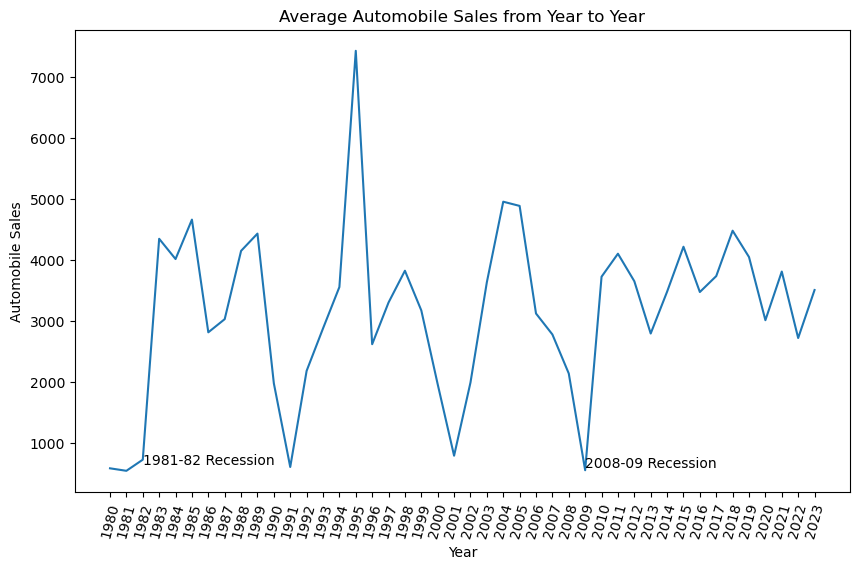

In [9]:
df_new = df.groupby(['Year'])['Automobile_Sales'].mean()

plt.figure(figsize=(10, 6))

df_new.plot(kind = 'line')
plt.xlabel('Year')
plt.ylabel('Automobile Sales')
plt.title('Average Automobile Sales from Year to Year')

plt.xticks(list(range(1980,2024)),rotation = 75)
plt.text(1982, 650, '1981-82 Recession')
plt.text(2009, 600, '2008-09 Recession')

plt.show()


### Trends in advertising expenditure correlate with automobile sales during non-recession periods

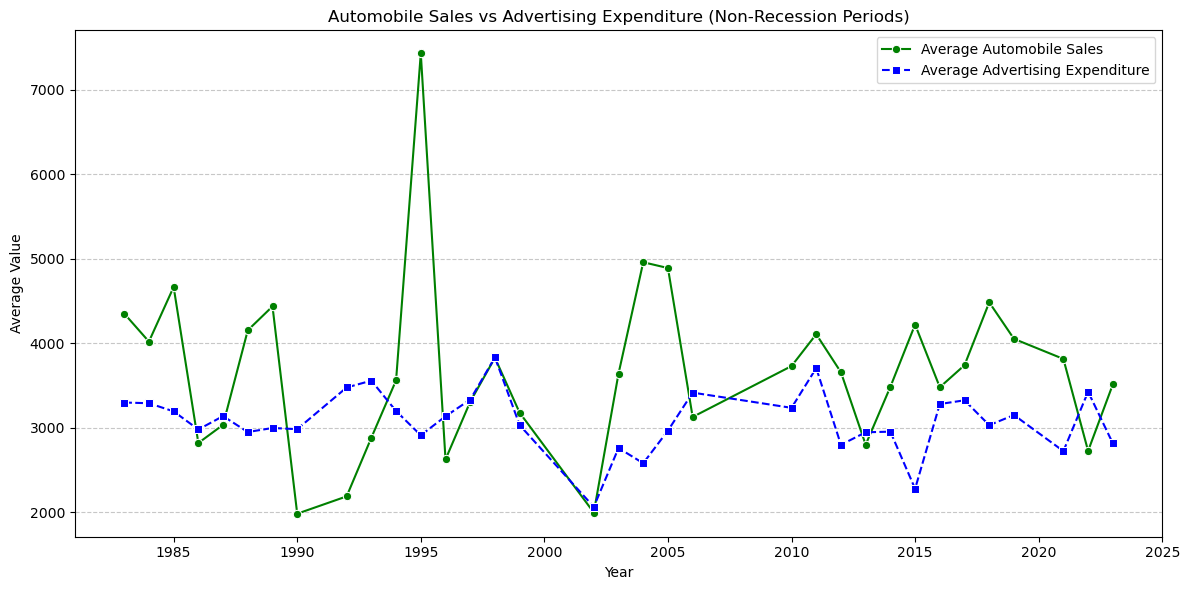

In [10]:
# Assuming 'df' is your dataset
df_non_rec = df[df['Recession'] == 0]

# Calculate average automobile sales and average advertising expenditure by year (non-recession)
df_trends = df_non_rec.groupby('Year', as_index=False).agg(
    Avg_Sales=('Automobile_Sales', 'mean'),
    Avg_Ad_Spend=('Advertising_Expenditure', 'mean')
)

# Create line plots for average sales and advertising expenditure over the years
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=df_trends,
    x='Year',
    y='Avg_Sales',
    marker='o',
    linestyle='-',
    color='green',
    label='Average Automobile Sales'
)

sns.lineplot(
    data=df_trends,
    x='Year',
    y='Avg_Ad_Spend',
    marker='s',
    linestyle='--',
    color='blue',
    label='Average Advertising Expenditure'
)

# Add labels, legend, title, and grid
plt.xlabel('Year')
plt.ylabel('Average Value')
plt.title('Automobile Sales vs Advertising Expenditure (Non-Recession Periods)')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show the plot
plt.tight_layout()
plt.show()

Automobile sales and advertising expenditure show different trends over time during non-recession periods. 
Higher advertising expenditure does not always directly translate to higher automobile sales, suggesting that other factors also strongly influence sales.
Year-to-year fluctuations in automobile sales indicate that demand is not perfectly stable, even in non-recession periods.
Advertising expenditure tends to be more consistent, while automobile sales are more variable, showing that sales are more sensitive to market conditions than marketing spend.

### Sales trend per vehicle type for a recession period with a non-recession period

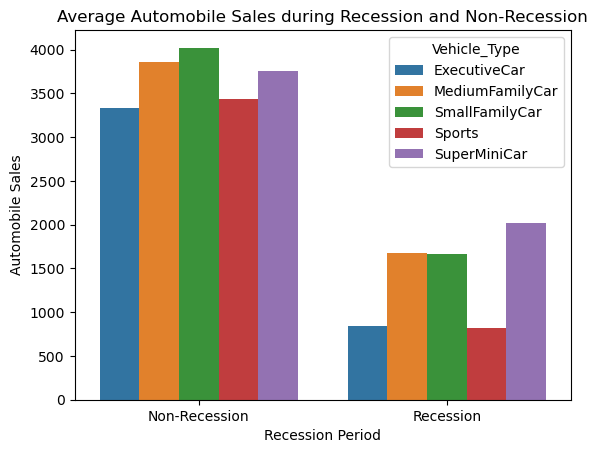

In [20]:
df_bar= df.groupby(['Recession','Vehicle_Type'])['Automobile_Sales'].mean().reset_index()

sns.barplot(x='Recession', y= 'Automobile_Sales', hue = 'Vehicle_Type', data= df_bar)
plt.xlabel('Recession Period')
plt.ylabel('Automobile Sales')
plt.title('Average Automobile Sales during Recession and Non-Recession')
plt.xticks(ticks=[0,1],labels=['Non-Recession', 'Recession'])

plt.show()


From this plot, we can understand that there is a drastic decline in the overall sales of the automobiles during recession.
However, the most affected type of vehicle is executivecar and sports.

### Sub plotting to compare the variations in GDP during recession and non-recession period 

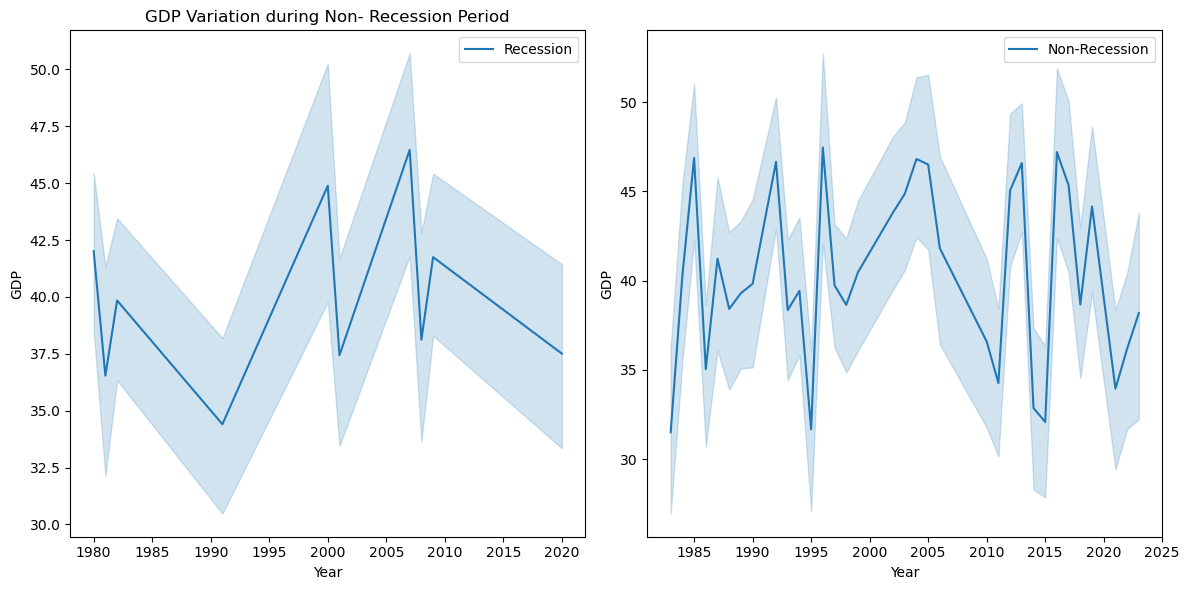

In [23]:
df_rec = df[df['Recession']==1]
df_nonrec = df[df['Recession']==0]

fig= plt.figure(figsize= (12,6))

ax0 = fig.add_subplot(1,2,1)
ax1 = fig.add_subplot(1,2,2)

sns.lineplot(x ='Year' , y ='GDP',data= df_rec,label = 'Recession', ax = ax0)
ax0.set_xlabel('Year')
ax0.set_ylabel('GDP')
ax0.set_title('GDP Variation during Recession Period')

sns.lineplot(x ='Year' , y ='GDP',data= df_nonrec,label = 'Non-Recession', ax = ax1)
ax1.set_xlabel('Year')
ax1.set_ylabel('GDP')
ax0.set_title('GDP Variation during Non- Recession Period')

plt.tight_layout()
plt.show()


From this plot, it is evident that GDP tends to be lower and more volatile during recessions, with significant fluctuations and uncertainty. In contrast, non-recessionary periods show a relatively higher GDP level but still exhibit some degree of variability.

### Bubble plot for displaying the impact of seasonality on Automobile Sales.

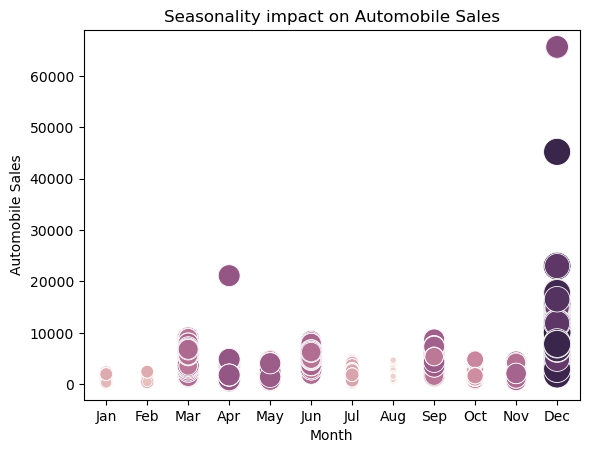

In [30]:
df_nonrec = df[df['Recession']==0]

sns.scatterplot(data=df_nonrec,x='Month',y='Automobile_Sales',size='Seasonality_Weight',sizes=(20, 400) ,hue='Seasonality_Weight', legend=False)

plt.xlabel('Month')
plt.ylabel('Automobile Sales')
plt.title('Seasonality impact on Automobile Sales')

plt.show()

From this plot, it is evident that seasonality has not affected on the overall sales. However, there is a drastic raise in sales in the month of April and December

### The relationship between consumer confidence and automobile sales during recessions.

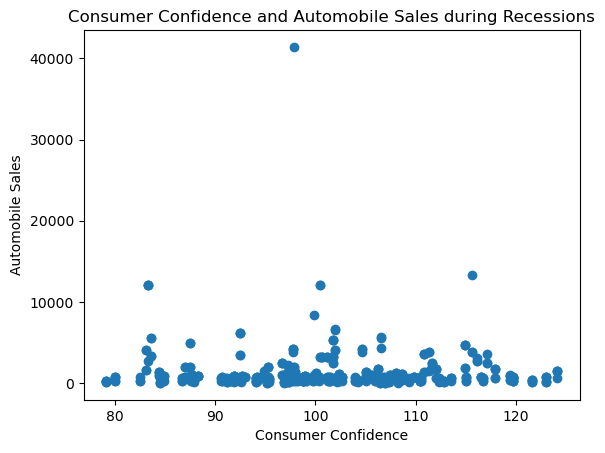

In [39]:
df_rec = df[df['Recession']==1]
plt.scatter(df_rec['Consumer_Confidence'], df_rec['Automobile_Sales'])

plt.title('Consumer Confidence and Automobile Sales during Recessions')
plt.xlabel('Consumer Confidence')
plt.ylabel('Automobile Sales')

plt.show()



### Relationship between Vehicle Price and Sales during Recessions

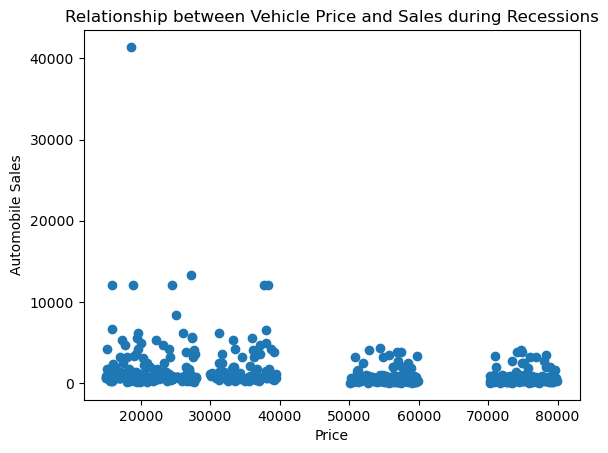

In [38]:
df_rec = df[df['Recession']==1]
plt.scatter(df_rec['Price'], df_rec['Automobile_Sales'])

plt.title('Relationship between Vehicle Price and Sales during Recessions')
plt.xlabel('Price')
plt.ylabel('Automobile Sales')

plt.show()


### Advertising expenditure of XYZAutomotives during recession and non-recession periods.


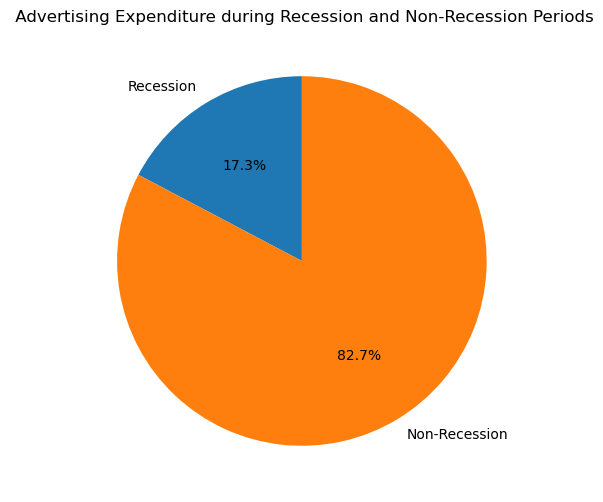

In [41]:
df_rec = df[df['Recession']==1]
df_nonrec = df[df['Recession']==0]

df_rec_tot = df_rec['Advertising_Expenditure'].sum()
df_nonrec_tot = df_nonrec['Advertising_Expenditure'].sum()

plt.figure(figsize=(8, 6))

labels = ['Recession', 'Non-Recession']
sizes = [df_rec_tot, df_nonrec_tot]
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90)
plt.title(' Advertising Expenditure during Recession and Non-Recession Periods')

plt.show()


It seems XYZAutomotives has been spending much more on the advertisements during non-recession periods as compared to during recession times. 

### Total Advertisement expenditure for each vehicle type during recession period.

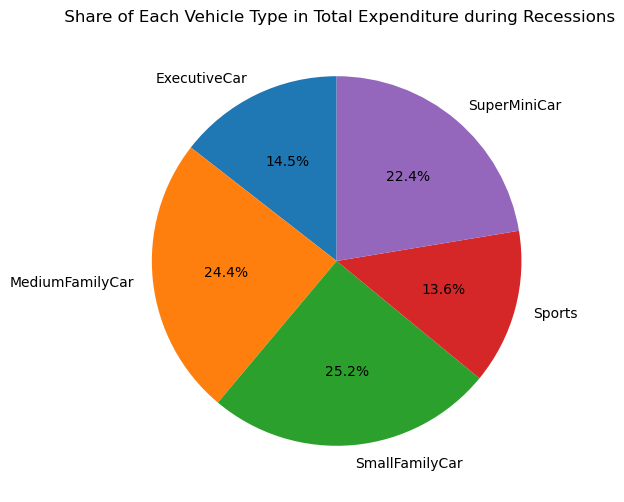

In [44]:
df_rec = df[df['Recession']==1]

df_vtype = df_rec.groupby('Vehicle_Type')['Advertising_Expenditure'].sum()

plt.figure(figsize=(8, 6))

labels = df_vtype.index 
sizes = df_vtype.values
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90)
plt.title(' Share of Each Vehicle Type in Total Expenditure during Recessions')

plt.show()

During recession the advertisements were mostly focued on low price range vehicle.

### The effect of the unemployment rate on vehicle type and sales during the Recession Period.

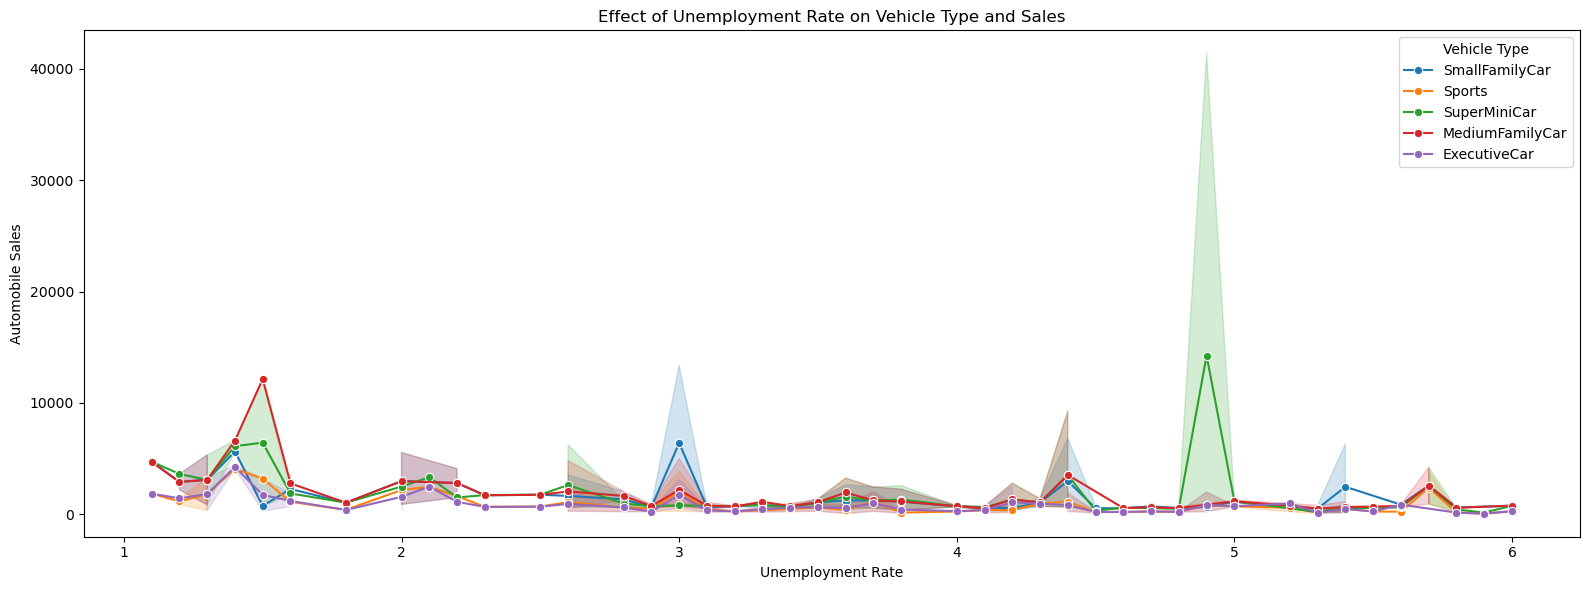

In [55]:
df_rec = df[df['Recession']==1]

plt.figure(figsize=(16,6))

sns.lineplot(data=df_rec,
            x='unemployment_rate',
            y='Automobile_Sales',
            hue='Vehicle_Type',
            marker='o'
)


plt.title('Effect of Unemployment Rate on Vehicle Type and Sales')
plt.xlabel('Unemployment Rate')
plt.ylabel('Automobile Sales')
plt.legend(title='Vehicle Type')

plt.tight_layout()
plt.show()


The plot shows that automobile sales decline as unemployment rates rise during a recession, with sharp drops beyond 3%. SuperMiniCars, SmallFamilyCars, and MediumFamilyCars exhibit high volatility, reflecting their sensitivity to economic uncertainty and changing consumer priorities.

### The Hightest Sales region/offices of the Company during Recession Period

In [8]:
import requests

url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DV0101EN-SkillsNetwork/Data%20Files/us-states.json"

response = requests.get(url)

with open("us-states.json", "wb") as file:
    file.write(response.content)

print("File downloaded successfully")

File downloaded successfully


In [10]:
df_rec = df[df['Recession']==1]

sales_by_city = df_rec.groupby('City')['Automobile_Sales'].sum().reset_index()
map1 = folium.Map(location=[37.0902, -95.7129], zoom_start=4)

choropleth = folium.Choropleth(
        geo_data= 'us-states.json',
        data=sales_by_city,
        columns=['City', 'Automobile_Sales'],
        key_on='feature.properties.name',
        fill_color='YlOrRd',
        fill_opacity=0.7,
        line_opacity=0.2,
        legend_name='Automobile Sales during Recession'
    ).add_to(map1)

choropleth.geojson.add_child(
        folium.features.GeoJsonTooltip(['name'], labels=True)
    )


map1